# Tratamento de dados dengue

Notebook para carregar os parquets de 2017, 2018 e 2019, aplicar a classe de limpeza e exibir o dataframe tratado.

In [1]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), Path.cwd() / "notebooks_limpeza"):
    if (candidate / "dengue_data_cleaner.py").exists():
        sys.path.insert(0, str(candidate))
        break

from dengue_data_cleaner import DengueDataCleaner

In [2]:
cleaner = DengueDataCleaner()

df_angel = cleaner.limpar_angel()
df_pedro = cleaner.limpar_pedro()
df_ruan = cleaner.limpar_ruan()
df_tratado = cleaner.juntar(df_angel, df_pedro, df_ruan)
df = df_tratado

print("Original:", cleaner.df.shape)
print("Angel:", df_angel.shape)
print("Pedro:", df_pedro.shape)
print("Ruan:", df_ruan.shape)
print("Tratado:", df_tratado.shape)

Original: (3259319, 119)
Angel: (2874235, 16)
Pedro: (3259319, 14)
Ruan: (3259319, 10)
Tratado: (2874235, 47)


In [3]:
print(list(df_tratado.columns))
display(df_tratado)

['age', 'age_years', 'sex', 'sex_label', 'pregnancy_status', 'pregnancy_status_label', 'race', 'race_label', 'education_level', 'education_level_label', 'occupation_code', 'occupation_name', 'residence_state', 'residence_state_label', 'residence_municipality', 'residence_health_region', 'disease_code', 'notification_date', 'notification_year', 'notification_month', 'notification_day', 'notification_epi_week', 'notif_municipality', 'notif_health_region', 'health_facility', 'symptom_onset_date', 'days_to_notification', 'symptom_epi_year', 'symptom_epi_week_number', 'fever', 'myalgia', 'headache', 'rash', 'vomiting', 'nausea', 'back_pain', 'conjunctivitis', 'arthritis', 'joint_pain', 'petechiae', 'retro_orbital_pain', 'tourniquet_test', 'hospitalized', 'hospital_state', 'hospital_state_label', 'final_classification', 'final_classification_label']


,age,age_years,sex,sex_label,pregnancy_status,pregnancy_status_label,race,race_label,education_level,education_level_label,...,arthritis,joint_pain,petechiae,retro_orbital_pain,tourniquet_test,hospitalized,hospital_state,hospital_state_label,final_classification,final_classification_label
0,19.0,16.0,F,Feminino,5.0,Não,4.0,Parda,5.0,Ensino médio incompleto,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,None,0.0,Descartado
1,25.0,22.0,F,Feminino,5.0,Não,4.0,Parda,5.0,Ensino médio incompleto,...,2.0,1.0,2.0,2.0,2.0,2.0,NaN,None,0.0,Descartado
2,18.0,15.0,M,Masculino,6.0,Não se aplica,4.0,Parda,2.0,4ª série completa,...,2.0,1.0,2.0,2.0,2.0,2.0,NaN,None,0.0,Descartado
3,11.0,8.0,F,Feminino,6.0,Não se aplica,4.0,Parda,NaN,None,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,None,1.0,Confirmado
4,18.0,15.0,F,Feminino,5.0,Não,4.0,Parda,5.0,Ensino médio incompleto,...,2.0,2.0,2.0,2.0,2.0,2.0,NaN,None,0.0,Descartado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2874230,16.0,15.0,F,Feminino,5.0,Não,4.0,Parda,5.0,Ensino médio incompleto,...,2.0,2.0,2.0,2.0,2.0,2.0,NaN,None,0.0,Descartado
2874231,20.0,18.0,M,Masculino,6.0,Não se aplica,4.0,Parda,6.0,Ensino médio completo,...,2.0,2.0,2.0,2.0,2.0,2.0,NaN,None,0.0,Descartado
2874232,9.0,8.0,M,Masculino,6.0,Não se aplica,4.0,Parda,2.0,4ª série completa,...,2.0,2.0,2.0,2.0,2.0,2.0,NaN,None,0.0,Descartado
2874233,50.0,48.0,M,Masculino,6.0,Não se aplica,4.0,Parda,6.0,Ensino médio completo,...,2.0,2.0,2.0,2.0,2.0,2.0,NaN,None,0.0,Descartado


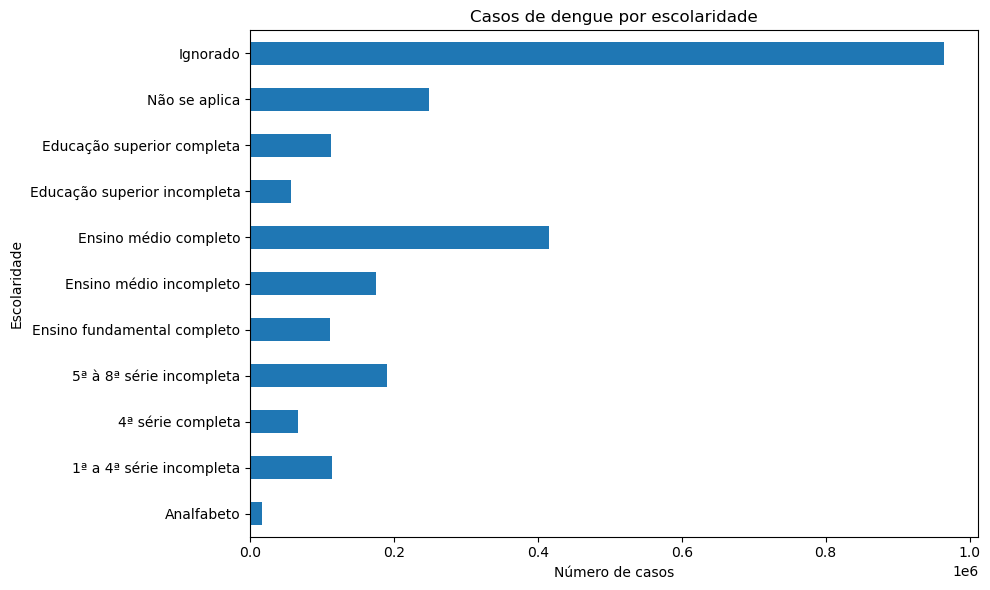

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

ordem_escolaridade = [
    "Analfabeto",
    "1ª a 4ª série incompleta",
    "4ª série completa",
    "5ª à 8ª série incompleta",
    "Ensino fundamental completo",
    "Ensino médio incompleto",
    "Ensino médio completo",
    "Educação superior incompleta",
    "Educação superior completa",
    "Não se aplica",
    "Ignorado",
]

casos = (
    df["education_level_label"]
    .value_counts()
    .reindex(ordem_escolaridade)
    .fillna(0)
)

plt.figure(figsize=(10, 6))
casos.plot(kind="barh")
plt.title("Casos de dengue por escolaridade")
plt.xlabel("Número de casos")
plt.ylabel("Escolaridade")
plt.tight_layout()
plt.show()

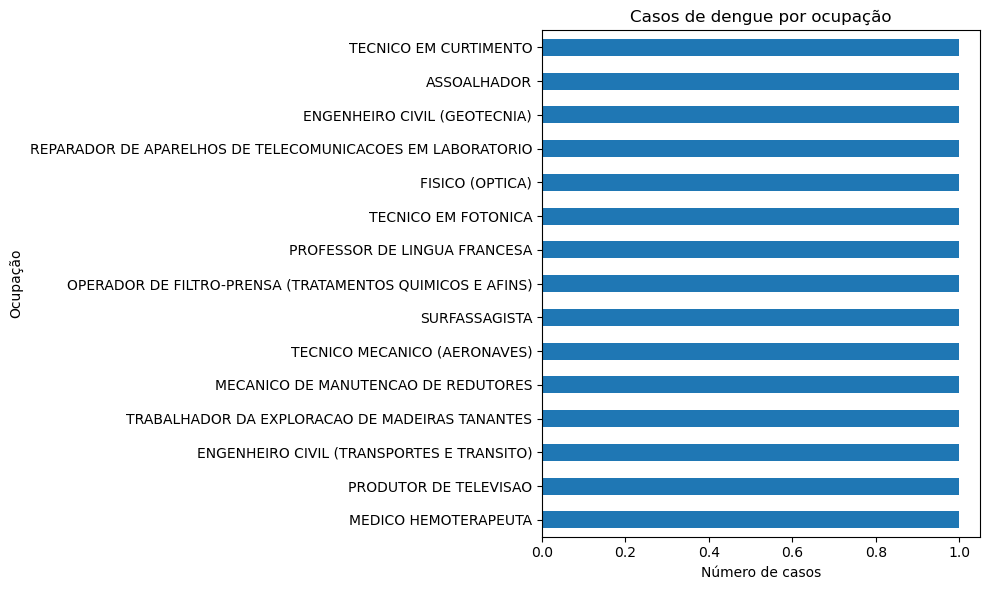

In [ ]:
import matplotlib.pyplot as plt

casos = (
    df["occupation_name"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 6))
casos.plot(kind="barh")
plt.title("Casos de dengue por ocupação")
plt.xlabel("Número de casos")
plt.ylabel("Ocupação")
plt.tight_layout()
plt.show()

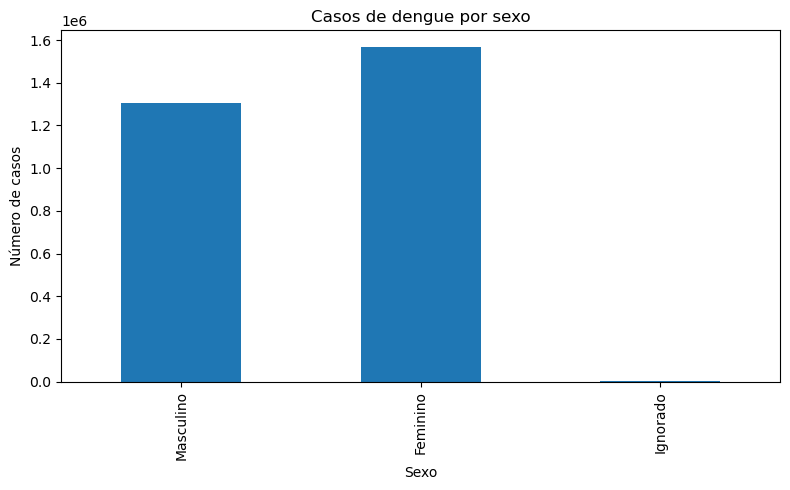

In [6]:
import matplotlib.pyplot as plt

casos = (
    df["sex_label"]
    .value_counts()
    .reindex(["Masculino", "Feminino", "Ignorado"])
    .fillna(0)
)

plt.figure(figsize=(8, 5))
casos.plot(kind="bar")
plt.title("Casos de dengue por sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

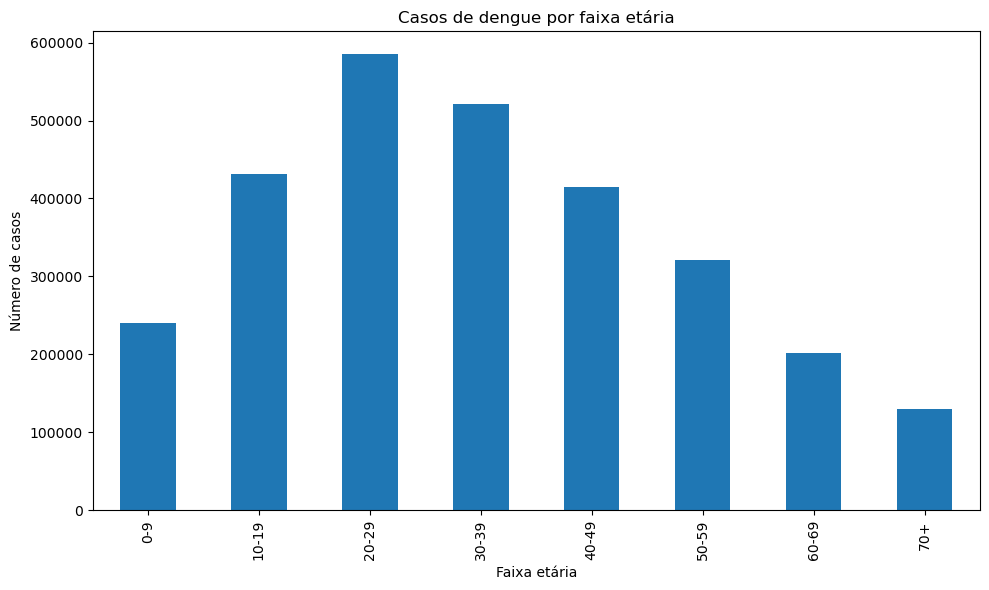

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

bins = [0, 9, 19, 29, 39, 49, 59, 69, 120]
labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"]

df["faixa_etaria"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

casos = (
    df["faixa_etaria"]
    .value_counts()
    .reindex(labels)
)

plt.figure(figsize=(10, 6))
casos.plot(kind="bar")
plt.title("Casos de dengue por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

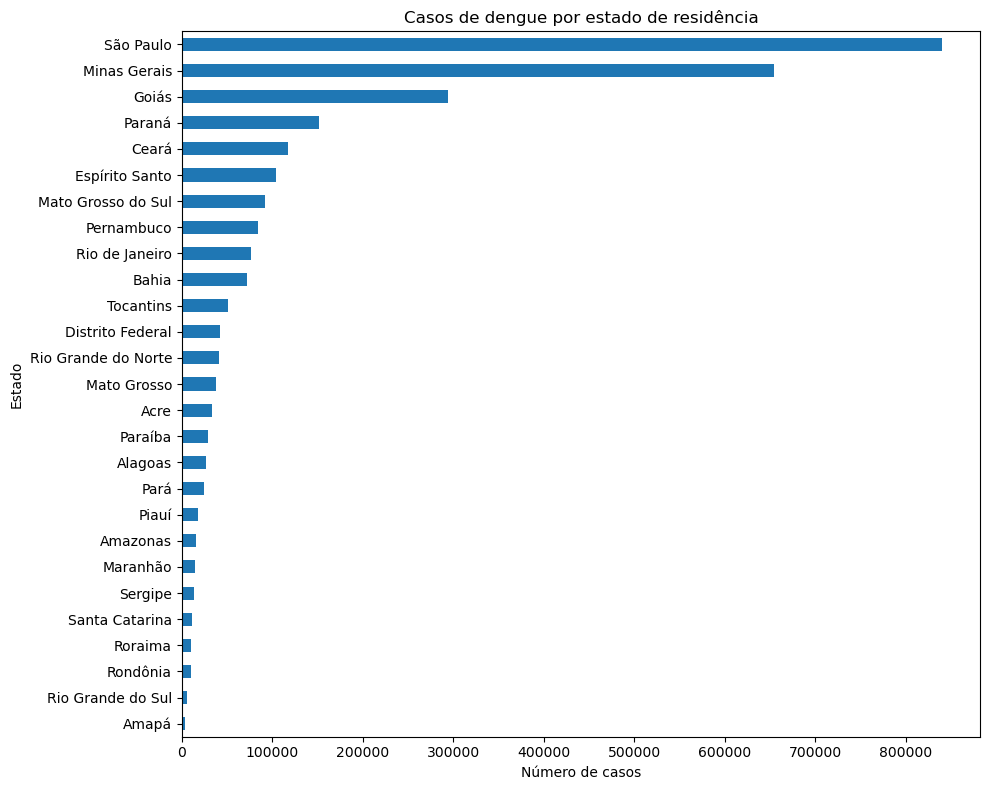

In [8]:
import matplotlib.pyplot as plt

casos = (
    df["residence_state_label"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 8))
casos.plot(kind="barh")
plt.title("Casos de dengue por estado de residência")
plt.xlabel("Número de casos")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

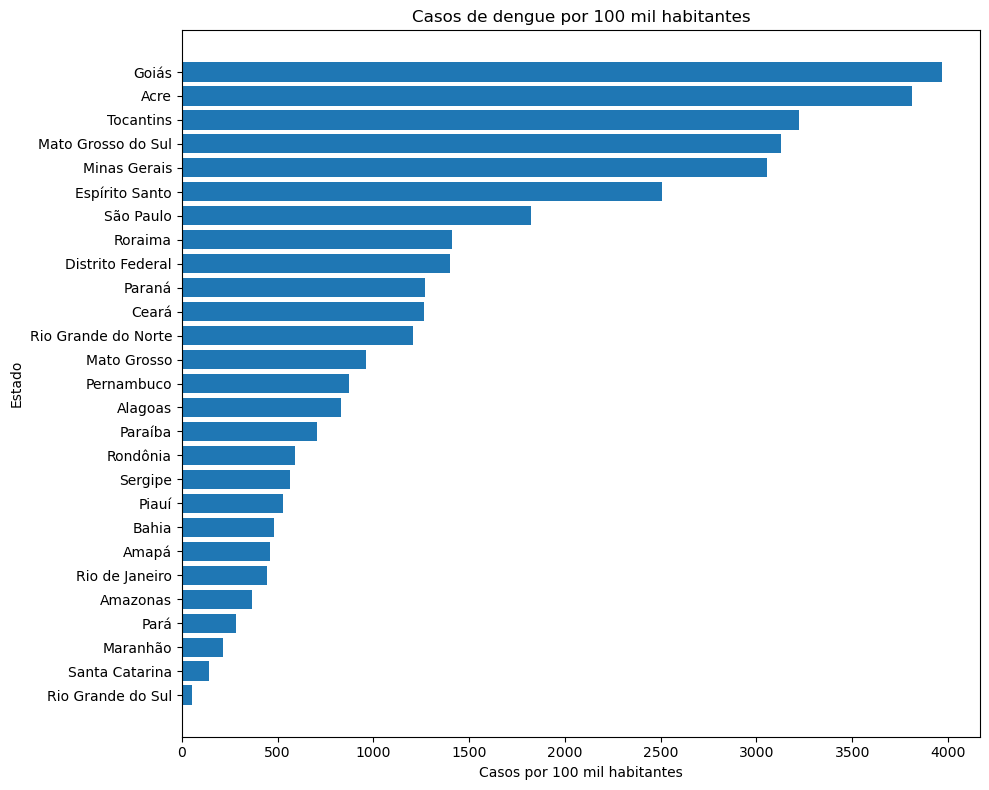

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# POPULAÇÃO POR ESTADO - IBGE (estimativa 1º de julho de 2025)
# Fonte: IBGE, Estimativas da População 2025
pop_estado = {
    "Rondônia": 1751950,
    "Acre": 884372,
    "Amazonas": 4321616,
    "Roraima": 738772,
    "Pará": 8711196,
    "Amapá": 806517,
    "Tocantins": 1586859,
    "Maranhão": 7018211,
    "Piauí": 3384547,
    "Ceará": 9268836,
    "Rio Grande do Norte": 3455236,
    "Paraíba": 4164468,
    "Pernambuco": 9562007,
    "Alagoas": 3220848,
    "Sergipe": 2299425,
    "Bahia": 14870907,
    "Minas Gerais": 21393441,
    "Espírito Santo": 4126854,
    "Rio de Janeiro": 17223547,
    "São Paulo": 46081801,
    "Paraná": 11890517,
    "Santa Catarina": 8187029,
    "Rio Grande do Sul": 11233263,
    "Mato Grosso do Sul": 2924631,
    "Mato Grosso": 3893659,
    "Goiás": 7423629,
    "Distrito Federal": 2996899,
}


# 2) CASOS POR 100 MIL HABITANTES
casos_estado = (
    df["residence_state_label"]
    .value_counts(dropna=False)
    .rename_axis("estado")
    .reset_index(name="casos")
)

base = casos_estado.copy()
base["populacao"] = base["estado"].map(pop_estado)

# Remove estados não mapeados e valores inválidos
base = base.dropna(subset=["populacao"])
base = base[base["populacao"] > 0]

base["casos_por_100k"] = (base["casos"] / base["populacao"]) * 100000

base = base.sort_values("casos_por_100k")

plt.figure(figsize=(10, 8))
plt.barh(base["estado"], base["casos_por_100k"])
plt.title("Casos de dengue por 100 mil habitantes")
plt.xlabel("Casos por 100 mil habitantes")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

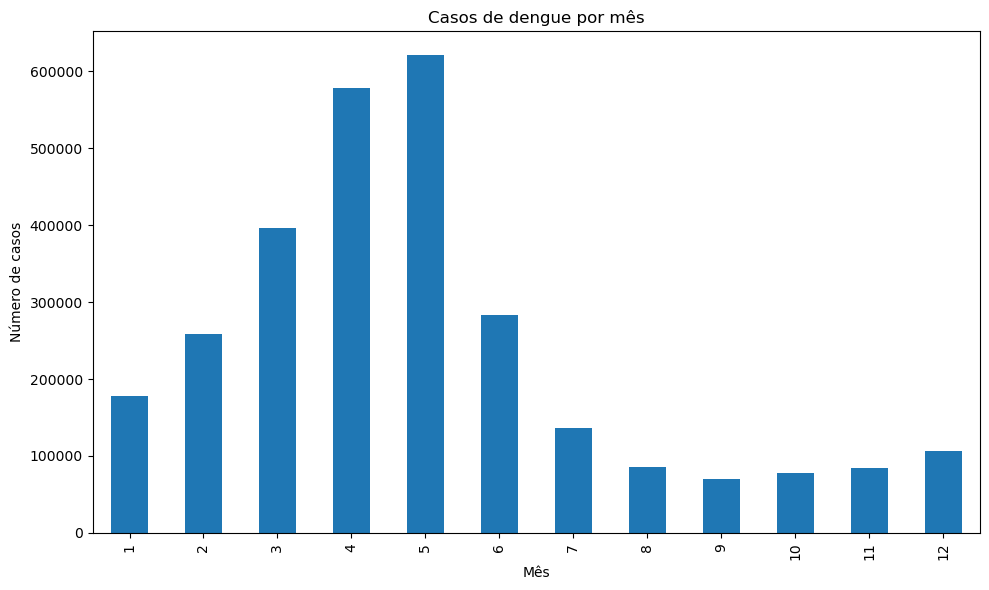

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df["notification_date"] = pd.to_datetime(df["notification_date"], errors="coerce")
df["mes"] = df["notification_date"].dt.month

ordem_meses = [i for i in range(1, 13)]

casos = (
    df["mes"]
    .value_counts()
    .reindex(ordem_meses)
)

plt.figure(figsize=(10, 6))
casos.plot(kind="bar")
plt.title("Casos de dengue por mês")
plt.xlabel("Mês")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

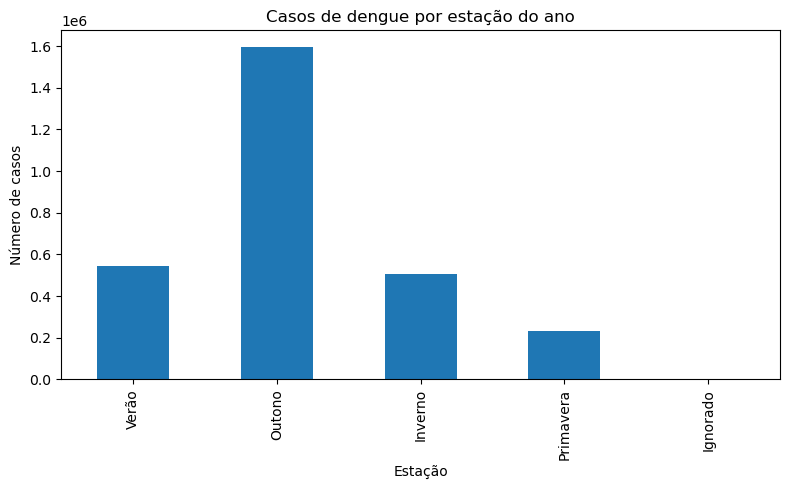

In [10]:
import matplotlib.pyplot as plt

def estacao(mes):
    if mes in [12, 1, 2]:
        return "Verão"
    elif mes in [3, 4, 5]:
        return "Outono"
    elif mes in [6, 7, 8]:
        return "Inverno"
    elif mes in [9, 10, 11]:
        return "Primavera"
    return "Ignorado"

df["estacao"] = df["notification_date"].dt.month.apply(estacao)

casos = (
    df["estacao"]
    .value_counts()
    .reindex(["Verão", "Outono", "Inverno", "Primavera", "Ignorado"])
    .fillna(0)
)

plt.figure(figsize=(8, 5))
casos.plot(kind="bar")
plt.title("Casos de dengue por estação do ano")
plt.xlabel("Estação")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

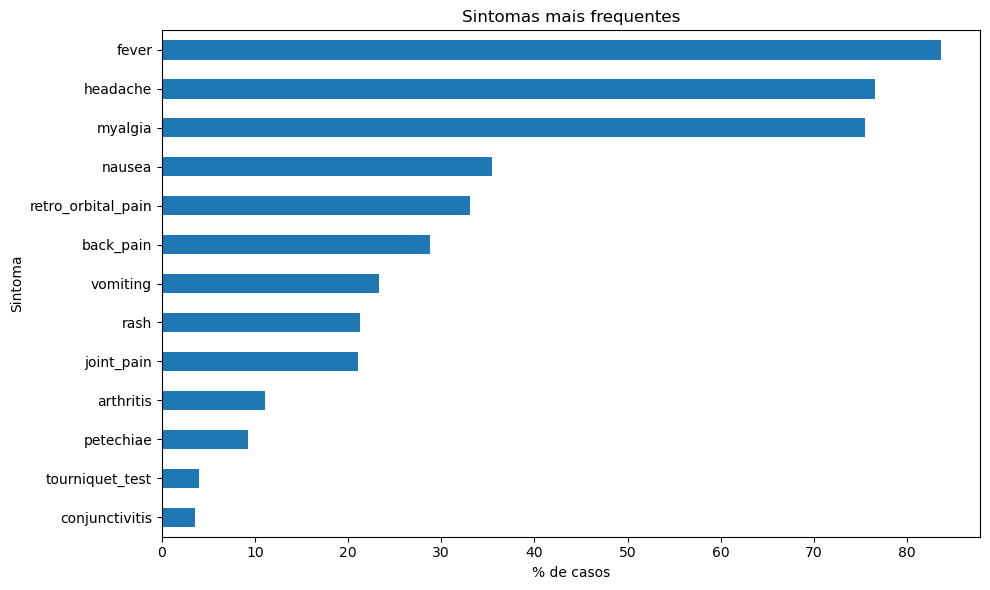

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

sintomas = [
    "fever",
    "myalgia",
    "headache",
    "rash",
    "vomiting",
    "nausea",
    "back_pain",
    "conjunctivitis",
    "arthritis",
    "joint_pain",
    "petechiae",
    "retro_orbital_pain",
    "tourniquet_test"
]

# Converte para numérico
for col in sintomas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Conta apenas valores iguais a 1 como "presente"
percentuais = {}
for col in sintomas:
    valido = df[col].isin([1, 2]).sum()   # ajuste se sua base usar outro padrão
    if valido == 0:
        percentuais[col] = 0
    else:
        percentuais[col] = (df[col].eq(1).sum() / valido) * 100

percentuais = pd.Series(percentuais).sort_values()

plt.figure(figsize=(10, 6))
percentuais.plot(kind="barh")
plt.title("Sintomas mais frequentes")
plt.xlabel("% de casos")
plt.ylabel("Sintoma")
plt.tight_layout()
plt.show()